# E-commerce Customer Segmentation Analysis

## Overview
This project analyzes e-commerce customer data to identify different customer segments based on purchasing behavior and engagement.

The goal is to understand customer value, discover patterns, and support targeted marketing strategies.

## Objectives
- Segment customers based on behavior
- Identify high-value customer groups
- Understand spending patterns and engagement
- Provide insights for business decision-making

## Dataset Description

The dataset includes:

- Customer demographics (Age, Gender, City)
- Membership type (Gold, Silver, Bronze)
- Transaction data (Total Spend, Items Purchased)
- Engagement metrics (Average Rating, Days Since Last Purchase)
- Discount usage and satisfaction level

## Methodology

- Data cleaning using pandas
- Feature selection based on customer behavior
- Customer segmentation using KMeans clustering
- Exploratory data analysis using matplotlib and seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
df = pd.read_csv("E-commerce Customer Behavior - Sheet1.csv")

print(df.head())
print(df.info())

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3               

In [4]:
df = df.copy()

numeric_cols = [
    'Age',
    'Total Spend',
    'Items Purchased',
    'Average Rating',
    'Days Since Last Purchase'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=numeric_cols)

print(df.isnull().sum())

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


In [5]:
rfm = df[['Customer ID', 'Total Spend', 'Items Purchased', 'Days Since Last Purchase']].copy()

rfm.columns = ['CustomerID', 'Monetary', 'Frequency', 'Recency']

print(rfm.head())
print(rfm.describe())

   CustomerID  Monetary  Frequency  Recency
0         101   1120.20         14       25
1         102    780.50         11       18
2         103    510.75          9       42
3         104   1480.30         19       12
4         105    720.40         13       55
       CustomerID     Monetary   Frequency     Recency
count  350.000000   350.000000  350.000000  350.000000
mean   275.500000   845.381714   12.600000   26.588571
std    101.180532   362.058695    4.155984   13.440813
min    101.000000   410.800000    7.000000    9.000000
25%    188.250000   502.000000    9.000000   15.000000
50%    275.500000   775.200000   12.000000   23.000000
75%    362.750000  1160.600000   15.000000   38.000000
max    450.000000  1520.100000   21.000000   63.000000


In [6]:
rfm_scaled = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_scaled = (rfm_scaled - rfm_scaled.mean()) / rfm_scaled.std()

print(rfm_scaled.head())

    Recency  Frequency  Monetary
0 -0.118190   0.336864  0.759043
1 -0.638992  -0.384987 -0.179202
2  1.146614  -0.866221 -0.924247
3 -1.085394   1.539948  1.753634
4  2.113818   0.096247 -0.345197


In [7]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_scaled = (rfm_features - rfm_features.mean()) / rfm_features.std()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster')[['Monetary', 'Frequency', 'Recency']].mean()

print(cluster_summary)

            Monetary  Frequency    Recency
Cluster                                   
0         593.902564  10.495726  42.888889
1         629.250862   9.663793  18.870690
2        1311.144444  17.615385  17.940171


In [9]:
def label_cluster(row):
    if row['Monetary'] == cluster_summary['Monetary'].max():
        return 'High-value customers'
    elif row['Monetary'] == cluster_summary['Monetary'].min():
        return 'Low-value customers'
    else:
        return 'Medium-value customers'


cluster_summary['Customer Group'] = cluster_summary.apply(label_cluster, axis=1)

print(cluster_summary)


rfm = rfm.merge(
    cluster_summary[['Customer Group']],
    left_on='Cluster',
    right_index=True,
    how='left'
)

print(rfm.head())

            Monetary  Frequency    Recency          Customer Group
Cluster                                                           
0         593.902564  10.495726  42.888889     Low-value customers
1         629.250862   9.663793  18.870690  Medium-value customers
2        1311.144444  17.615385  17.940171    High-value customers
   CustomerID  Monetary  Frequency  Recency  Cluster          Customer Group
0         101   1120.20         14       25        2    High-value customers
1         102    780.50         11       18        1  Medium-value customers
2         103    510.75          9       42        0     Low-value customers
3         104   1480.30         19       12        2    High-value customers
4         105    720.40         13       55        0     Low-value customers


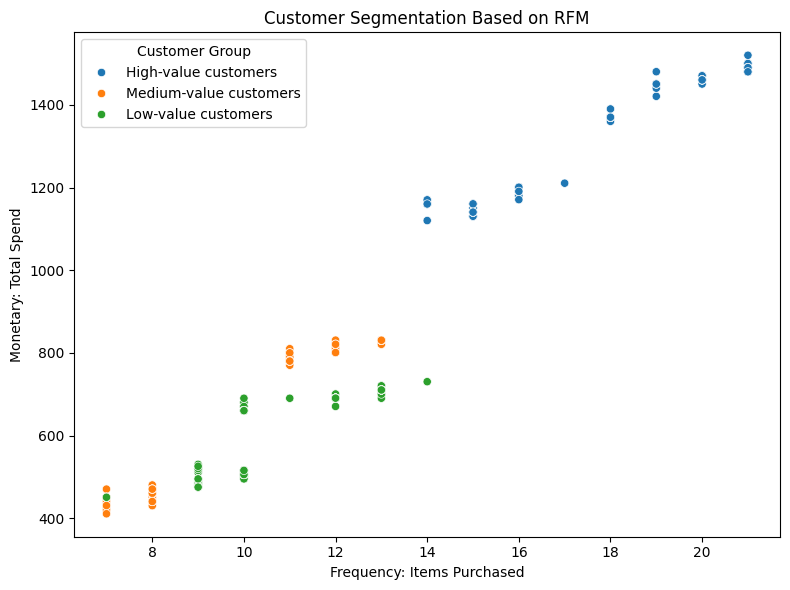

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Customer Group'
)

plt.title('Customer Segmentation Based on RFM')
plt.xlabel('Frequency: Items Purchased')
plt.ylabel('Monetary: Total Spend')
plt.tight_layout()
plt.show()

Customer Group
High-value customers      117
Low-value customers       117
Medium-value customers    116
Name: count, dtype: int64


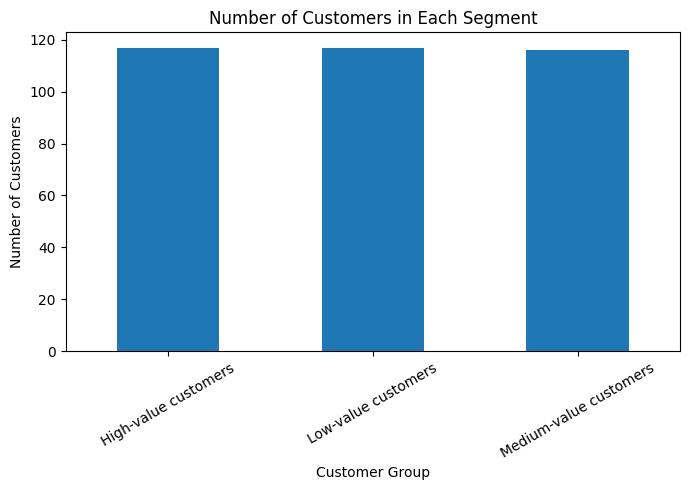

In [11]:
group_count = rfm['Customer Group'].value_counts()

print(group_count)

plt.figure(figsize=(7, 5))
group_count.plot(kind='bar')
plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [12]:
# Create target variable for prediction
# High-value customers are defined as the top 25% by total spending.
df['High_Value'] = df['Total Spend'] > df['Total Spend'].quantile(0.75)

In [13]:
#Build prediction model
features = [
    'Age',
    'Average Rating',
    'Days Since Last Purchase'
]

X = df[features]
y = df['High_Value']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=4
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [14]:
# Model evaluation

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.9857

Classification Report:
              precision    recall  f1-score   support

       False       0.98      1.00      0.99        53
        True       1.00      0.94      0.97        17

    accuracy                           0.99        70
   macro avg       0.99      0.97      0.98        70
weighted avg       0.99      0.99      0.99        70


Confusion Matrix:
[[53  0]
 [ 1 16]]


Days Since Last Purchase    0.217564
Age                         0.357925
Average Rating              0.424511
dtype: float64


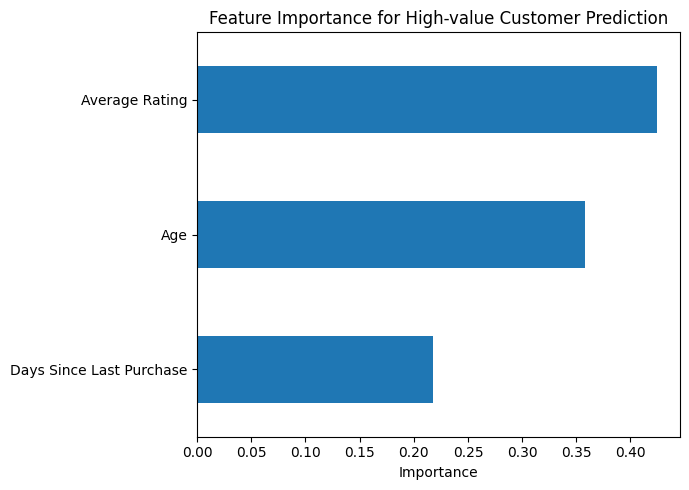

In [15]:
#Feature importance

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values()

print(importance)

plt.figure(figsize=(7, 5))
importance.plot(kind='barh')
plt.title('Feature Importance for High-value Customer Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Key Insights

- Customers can be grouped into distinct segments based on spending and activity levels
- High-value customers contribute significantly more revenue
- Customers with lower engagement tend to spend less and purchase less frequently
- Membership level is strongly related to customer value

## Business Recommendations

- Focus marketing efforts on high-value customers to increase retention
- Provide personalised offers to medium-value customers to boost spending
- Re-engage low-activity customers through promotions or incentives

## Conclusion

This project demonstrates how customer segmentation can help businesses better understand their users and apply targeted strategies to improve revenue and customer satisfaction.